## Generate Plots for Miniexample

For each scenario generate a exemplary plot with cdf

In [14]:
import itertools
import os
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib import cm, patches
import numpy as np
import scipy.stats

sys.path.append("../")
from helper import load_data, preprocess, data_source_release

sc_dict = data_source_release.get_sc_dict()
data_dir = data_source_release.get_data_dir()

USE = ("SAT", "UNSAT")

%matplotlib inline
plt.style.use('bmh') #seaborn-deep')
dpi=100

c = [cm.tab20b(x) for x in np.linspace(0, 0.19, 10)]
np.random.shuffle(c)
green_colors = itertools.cycle(c)

c = [cm.tab20b(x) for x in np.linspace(0.61, 0.79, 10)]
np.random.shuffle(c)
red_colors = itertools.cycle(c)

c = [cm.tab20b(x) for x in np.linspace(0.21, 0.34, 10)]
np.random.shuffle(c)
other_colors1 = itertools.cycle(c)

c = [cm.tab20b(x) for x in np.linspace(0.41, 0.54, 10)]
np.random.shuffle(c)
other_colors2 = itertools.cycle(c)

blue_colors= itertools.cycle(['#92c5de','#4393c3','#2166ac','#053061'])

clasp_factoring
Train data loaded
Test data loaded
../data/clasp-3.0.4-p8_rand_factoring/features.txt
(2000, 113) (2000, 100)
Discarding 0 (2000) instances because of CRASHED
Discarding 0 (2000) instances because of TIMEOUT
Discarding 0 (2000) instances because not stated TIMEOUTS
Discarding 0 (2000) instances because of constant features
Discarding 0 (2000) instances because of UNSAT
(2000, 113)
0.025243461499999995


/home/hgv/miniconda3/envs/distnetenv/lib/python3.5/site-packages/matplotlib/cbook/__init__.py:424: MatplotlibDeprecationWarning: 
Passing one of 'on', 'true', 'off', 'false' as a boolean is deprecated; use an actual boolean (True/False) instead.
  warn_deprecated("2.2", "Passing one of 'on', 'true', 'off', 'false' as a "


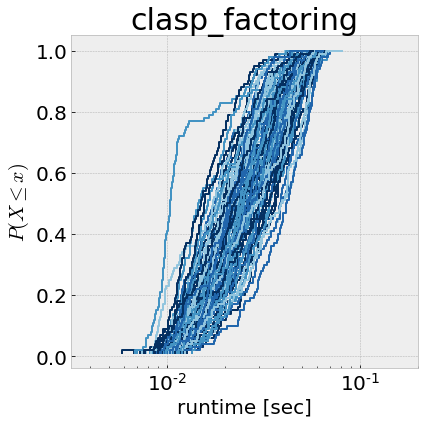

saps-CVVAR
Train data loaded
Could not find test data
../data/CP06_CV-VAR/features.txt
(20000, 54) (20000, 100)
Discarding 0 (20000) instances because of CRASHED
Discarding 9989 (20000) instances because of TIMEOUT
Discarding 0 (10011) instances because not stated TIMEOUTS
Discarding 0 (10011) instances because of constant features
Discarding 0 (10011) instances because of UNSAT
(10011, 54)
0.04769541283987613


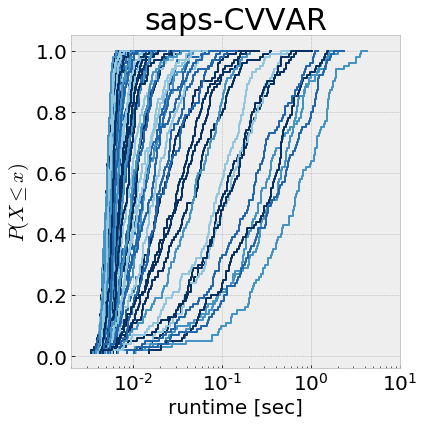

spear_qcp
Train data loaded
Test data loaded
../data/spear_qcp-hard/features.txt
(11962, 100) (11962, 100)
Discarding 0 (11962) instances because of CRASHED
Discarding 3816 (11962) instances because of TIMEOUT
Discarding 0 (8146) instances because not stated TIMEOUTS
Discarding 4 (8146) instances because of constant features
Discarding 70 (8142) instances because of UNSAT
(8072, 100)
21.066878935703667


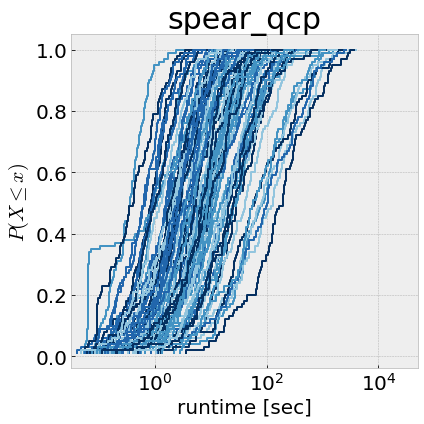

yalsat_qcp
Train data loaded
Test data loaded
../data/yalsat_qcp-hard/features.txt
(11962, 100) (11962, 100)
Discarding 0 (11962) instances because of CRASHED
Discarding 215 (11962) instances because of TIMEOUT
Discarding 0 (11747) instances because not stated TIMEOUTS
Discarding 4 (11747) instances because of constant features
Discarding 0 (11743) instances because of UNSAT
(11743, 100)
6.940389881376138


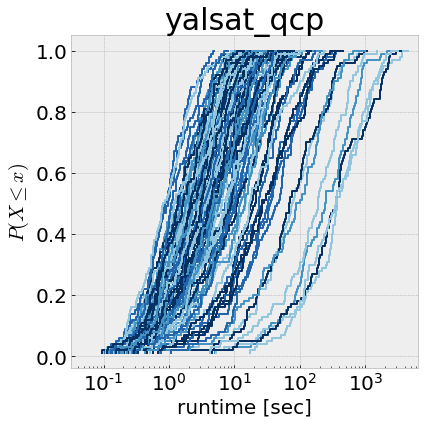

spear_swgcp
Train data loaded
Test data loaded
../data/spear_smallworlds/features.txt
(12499, 100) (12499, 100)
Discarding 0 (12499) instances because of CRASHED
Discarding 34 (12499) instances because of TIMEOUT
Discarding 0 (12465) instances because not stated TIMEOUTS
Discarding 0 (12465) instances because of constant features
Discarding 1283 (12465) instances because of UNSAT
(11182, 100)
1.1807831880701123


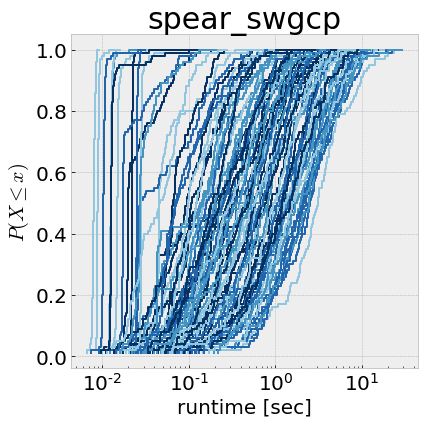

yalsat_swgcp
Train data loaded
Test data loaded
../data/yalsat_smallworlds/features.txt
(12499, 100) (12499, 100)
Discarding 0 (12499) instances because of CRASHED
Discarding 1317 (12499) instances because of TIMEOUT
Discarding 0 (11182) instances because not stated TIMEOUTS
Discarding 0 (11182) instances because of constant features
Discarding 0 (11182) instances because of UNSAT
(11182, 100)
5.8800318030763705


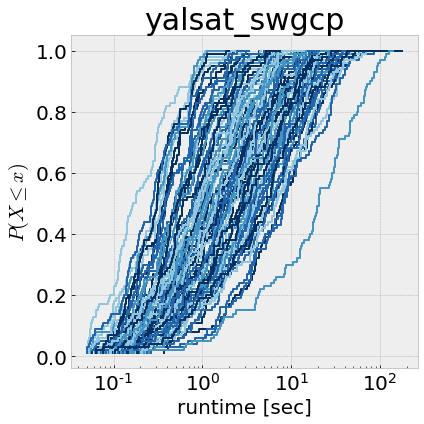

lpg-zeno
Train data loaded
Test data loaded
../data/lpg-zenotravel/features.txt
(4000, 305) (4000, 100)
Discarding 0 (4000) instances because of CRASHED
Discarding 1 (4000) instances because of TIMEOUT
Discarding 0 (3999) instances because not stated TIMEOUTS
Discarding 0 (3999) instances because of constant features
Discarding 0 (3999) instances because of UNSAT
(3999, 305)
25.074094853713426


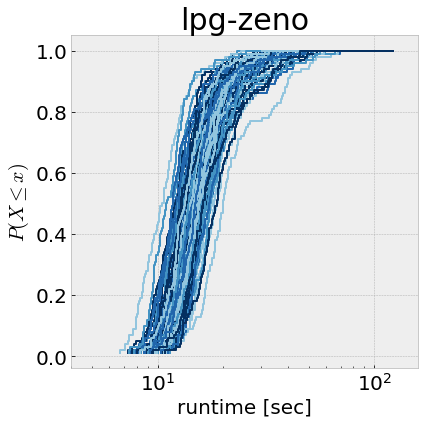

In [15]:
import matplotlib.colors as colors
import matplotlib.cm as cm

limit_dict = {"clasp_factoring": [10**-2.5, 10**-0.7],
              "lpg-zeno":  [10**0.6, 10**2.2],
              "saps-CVVAR": [10**-2.7, 10**1],
              "spear_qcp": [10**-1.5, 10**4.7],
              "yalsat_qcp": [10**-1.5, 10**3.8]
             }

range_dict = {"clasp_factoring": [0, 100],
              "lpg-zeno": [0, 100],
              "saps-CVVAR": [7000, 7100],
              "spear_qcp": [0, 100],
              "yalsat_qcp": [0, 100],
              "spear_swgcp": [0, 100],
              "yalsat_swgcp": [0, 100]
             }

for SC in ["clasp_factoring",
  "saps-CVVAR",
  "spear_qcp",
  "yalsat_qcp",
  "spear_swgcp",
  "yalsat_swgcp",
  "lpg-zeno",
           ]:
    print(SC)
    data, _, sat_ls = load_data.get_data(scenario=SC, data_dir=data_dir, sc_dict=sc_dict, retrieve=sc_dict[SC]['use'])
    print(data.mean())
    dist_name = "lognorm_floc"
    ann_name = "LOG"
    if SC == "clasp_factoring":
        dist_name = "invgauss_floc"
        ann_name = "INV"
    
    fig, ax = plt.subplots(figsize=(6,6))
    for idx, i in enumerate(range(*range_dict[SC])): #data.shape[0]):
        sorted = np.sort(data[i, :])
        
        yvals = np.arange(1,len(sorted)+1)/float(len(sorted))
        cval = next(blue_colors)
        ax.step(sorted, yvals, c=cval, linewidth=2)

    ax.set_ylabel(r"$P(X \leq x)$", fontsize=20)
    ax.tick_params(
    axis='both',       # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    top='off',         # ticks along the top edge are off
    labelsize=20)
    
    
    ax.set_xlabel("runtime [sec]", fontsize=20)
    if SC not in ["spear_swgcp","yalsat_swgcp"]:
        ax.set_xlim(limit_dict[SC])
    ax.set_xscale('log')
    ax.set_title("%s" % SC, fontsize=30)
    plt.tight_layout()
    plt.show()